<a href="https://colab.research.google.com/github/Royst97/DSRP_Roy/blob/main/DSRP_2026_Royston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Stuff:

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("/content/lendingclub_loans_export.csv")

Exploring the Data:

In [32]:
print(df.dtypes, "\n")
print(df.info())

emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint            object
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever    

In [33]:

print(df.shape, "\n")
print(df.columns)

(10000, 55) 

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Cleaning the Data:

In [34]:
#Change NA values to null
df = df.replace("NA", np.nan)

#All loans were 2018, remove year from issue month
df["issue_month"] = pd.to_datetime(df["issue_month"], format="%b-%Y").dt.strftime

#Grade information included in subgrade
df.drop(columns = ["grade"], inplace = True)

#Dropping columns with excessive null values and do not pertain to my research
df = df.drop(columns=["annual_income_joint","verification_income_joint","debt_to_income_joint","months_since_last_delinq","months_since_90d_late"])



In [35]:
#Checking for duplicates
print(df.duplicated().sum(), "\n")

print(df.info())

0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 49 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         10000 non-null  int64  
 8   earliest_credit_line              10000 non-null  int64  
 9   inquiries_last_12m                10000 non-null  int64  
 10  total_credit_lines                10000 non-null  int64  
 11  open_credit_lines                 10000 non-null  int64  
 12  t

Visuals

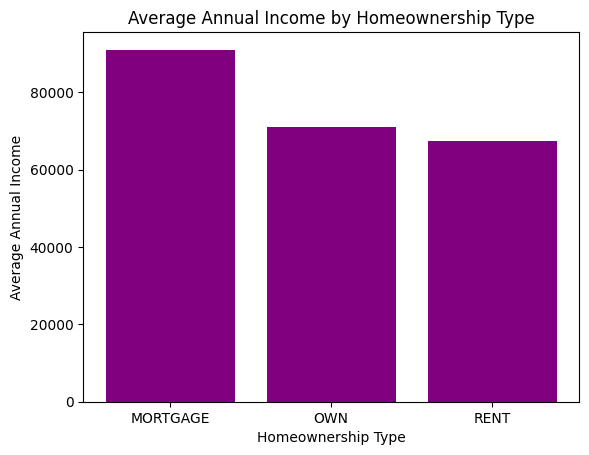

In [45]:
#I might want to do a question based on house ownership compared to something else so this visual is in preparation


avg_anninc = df.groupby("homeownership")["annual_income"].mean()

plt.bar(avg_anninc.index, avg_anninc.values, color="purple")
plt.title("Average Annual Income by Homeownership Type")
plt.xlabel("Homeownership Type")
plt.ylabel("Average Annual Income")

plt.show()

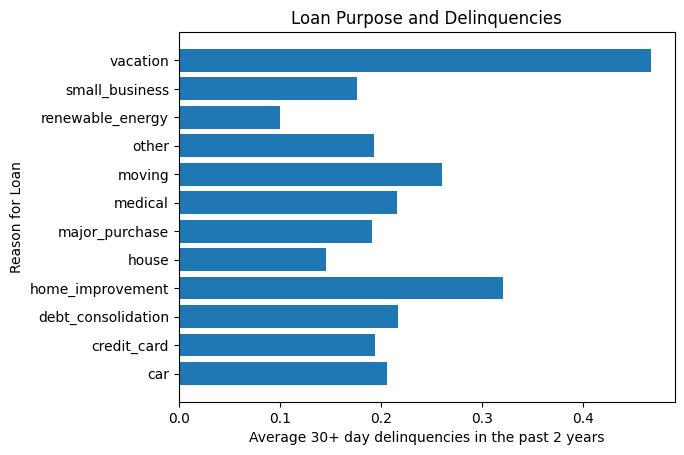

In [38]:
avg_delinq = df.groupby("loan_purpose")["delinq_2y"].mean()

plt.barh(avg_delinq.index, avg_delinq.values)
plt.title("Loan Purpose and Delinquencies")
plt.xlabel("Average 30+ day delinquencies in the past 2 years")
plt.ylabel("Reason for Loan")

plt.show()

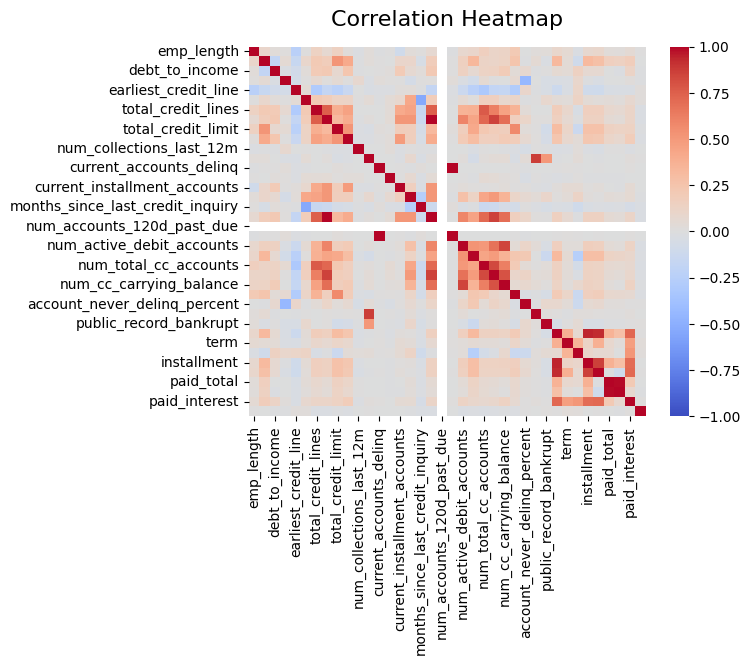

In [43]:
corr_matrix = df.corr(numeric_only=True)


# 4. Generate the heatmap with key aesthetic options
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
)

# 5. Add a title and show the plot
plt.title("Correlation Heatmap", fontsize=16, pad=15)
plt.show()